In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df=data.copy()

In [3]:
df.drop(columns="customerID",inplace=True)

In [4]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
#sns.pairplot(data=df,hue='Churn')
plt.show()

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [9]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(7021,), dtype=object)

In [10]:
pd.to_numeric(df.TotalCharges,errors='coerce').isna().sum()

np.int64(11)

In [11]:
#sns.histplot(x='MonthlyCharges',data=df,edgecolor='red',bins=[10,20,30,40,50,60,70,80,90,100,110,120])
plt.show()


In [12]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [13]:
df.loc[pd.to_numeric(df["TotalCharges"], errors="coerce").isna(), "TotalCharges"].unique()


array([' '], dtype=object)

In [14]:
df.shape

(7021, 20)

In [15]:
df1=df[df.TotalCharges!=' ']

In [16]:
df.reset_index(inplace=True)

In [17]:
df1.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [18]:
df1.TotalCharges=pd.to_numeric(df1.TotalCharges)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\695980592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges=pd.to_numeric(df1.TotalCharges)


In [19]:
df1.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [20]:
df1.replace("No phone service","No",inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\2225408447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace("No phone service","No",inplace=True)


In [21]:
df1.replace("No internet service","No",inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\3316021580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace("No internet service","No",inplace=True)


In [22]:
list=['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

In [23]:
for i in list:
    df1[i].replace({"Yes":1,"No":0},inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\3717242158.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[i].replace({"Yes":1,"No":0},inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\3717242158.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[i].replace({"Yes":1,"No"

In [24]:
df1['gender'].replace({"Female":0,"Male":1},inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\981094346.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({"Female":0,"Male":1},inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_14412\981094346.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].repl

In [25]:
df2=pd.get_dummies(data=df1,columns=["InternetService","Contract","PaymentMethod"],dtype=int)

In [26]:
for column in df2.columns:
    print(f"{column}={df2[column].unique()}")


gender=[0 1]
SeniorCitizen=[0 1]
Partner=[1 0]
Dependents=[0 1]
tenure=[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService=[0 1]
MultipleLines=[0 1]
OnlineSecurity=[0 1]
OnlineBackup=[1 0]
DeviceProtection=[0 1]
TechSupport=[0 1]
StreamingTV=[0 1]
StreamingMovies=[0 1]
PaperlessBilling=[1 0]
MonthlyCharges=[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges=[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn=[0 1]
InternetService_DSL=[1 0]
InternetService_Fiber optic=[0 1]
InternetService_No=[0 1]
Contract_Month-to-month=[1 0]
Contract_One year=[0 1]
Contract_Two year=[0 1]
PaymentMethod_Bank transfer (automatic)=[0 1]
PaymentMethod_Credit card (automatic)=[0 1]
PaymentMethod_Electronic check=[1 0]
PaymentMethod_Mailed check=[0 1]


In [27]:
list2=['tenure','MonthlyCharges','TotalCharges']

In [28]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
df2[list2]=sc.fit_transform(df2[list2])

In [29]:
df2.sample(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1495,0,0,1,1,0.718310,1,1,1,1,1,...,0,1,0,1,0,0,1,0,0,0
3217,0,0,0,0,0.014085,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x=df2.drop(columns="Churn",axis=1)
y=df2['Churn']

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [33]:
model=keras.Sequential([
    keras.layers.Dense(20,input_shape=(26,),activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(15,activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1,activation='sigmoid')
])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss='BinaryFocalCrossentropy',
    metrics=['accuracy']
)

In [50]:
model.fit(x_train,y_train,epochs=100,batch_size=30)

Epoch 1/100


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7826 - loss: 0.1123
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7833 - loss: 0.1127
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7946 - loss: 0.1112
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7894 - loss: 0.1126
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7882 - loss: 0.1125
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7810 - loss: 0.1138
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7855 - loss: 0.1115
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7912 - loss: 0.1118
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7898 - loss: 0.1116
Epoch 10/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7949 - loss: 0.1114
Epoch 11/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7905 - loss: 0.1114
Epoch 12/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [52]:
model.evaluate(x_test,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8245 - loss: 0.1084


[0.10838398337364197, 0.8245363831520081]

In [37]:
p_pre=model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [38]:
y_pre=[]
for i in p_pre :
    if i>0.5:
        y_pre.append(1)
    else:
        y_pre.append(0)

In [39]:
from sklearn.metrics import confusion_matrix,classification_report

In [40]:
y_pre[:10]

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

In [41]:
y_test[:10]

6882    0
6752    0
245     0
1889    0
6830    0
3135    1
5997    0
3878    0
2717    0
2792    0
Name: Churn, dtype: int64

In [42]:
print(classification_report(y_test,y_pre))

              precision    recall  f1-score   support

           0       0.81      0.98      0.88      1081
           1       0.72      0.21      0.33       321

    accuracy                           0.80      1402
   macro avg       0.76      0.59      0.61      1402
weighted avg       0.79      0.80      0.76      1402



In [43]:
cm=confusion_matrix(y_test,y_pre)

<Axes: >

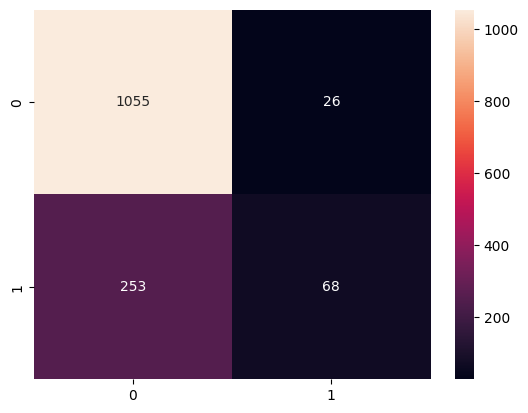

In [44]:
sns.heatmap(cm,fmt='d',annot=True)